# Numerical Simulation Laboratory (NSL) 
##  Exercises 07:  Monte Carlo (NVT) and Molecular Dynamic (NVE) Simulation for a System in Liquid Phase

___
### Exercise 07.1
In the NSL simulator code we have provided, include tail corrections for potential energy, $U$, and pressure $P$.
___

### Implementation

#### Obiettivo 
L'obiettivo dell'esercizio è includere nel codice NSL simulator le correzioni di coda per l'energia potenziale ( $U$ ) e la pressione ( $P$ ) in un sistema descritto dal potenziale di Lennard-Jones. Queste correzioni sono necessarie per tenere conto delle interazioni tra particelle oltre il raggio di cut-off ( $r_c$ ), che vengono troncate durante la simulazione.

Attraverso il troncamento il calcolo è reso più efficiente. Le interazioni tra le particelle a distanza maggiore di $r_c$ non vengono calcolate esplicitamente, quindi il tempo di calcolo è ridotto. Bisogna però osservare che il potenziale di Lennard-Jones ha una coda attrattiva (termine $\sim -  1/r^6$), dunque le coppie di particelle con $r>r_c$ danno ancora un contributo medio a energia e pressione. Per questo motivo è necessario introdurre delle correzioni di coda che tengano conto dei contributi altrimenti trascurati.

#### Correzioni di Coda
1. **Energia potenziale:** La correzione di coda per l'energia potenziale per particella è data da  $$U_{\text{tail}} = \frac{8\pi \rho}{3} \left( \frac{1}{3r_c^9} - \frac{1}{r_c^3} \right)\, , $$ 
dove ( $\rho$ ) è la densità ridotta e ( $r_c$ ) è il raggio di cut-off.

2. **Pressione:** La correzione di coda per la pressione è data da  $$P_{\text{tail}} = \frac{32\pi \rho^2}{9} \left( \frac{1}{3r_c^9} - \frac{1}{2r_c^3} \right)\, .$$

#### Implementazione Correzioni nel File system.cpp
Le correzioni di coda sono state implementate nella funzione initialize_properties() del file system.cpp. Ecco i passaggi principali:

1. Calcolo di  $U_{\text{tail}}$:
La correzione di coda per l'energia potenziale è calcolata e salvata nella variabile _vtail:
```c++
_vtail = (8.0 / 3.0) * M_PI * _rho * (1.0 / (3.0 * pow(_r_cut, 9)) - 1.0 / pow(_r_cut, 3));
```

2. Calcolo di $P_{\text{tail}}$:
La correzione di coda per la pressione è calcolata e salvata nella variabile _ptail:
```c++
_ptail = 32.0 * M_PI * _rho * (1.0 / (9.0 * pow(_r_cut, 9)) - 1.0 / (6.0 * pow(_r_cut, 3)));
```

3. Integrazione delle correzioni:
Durante il calcolo delle proprietà termodinamiche nella funzione measure(), le correzioni di coda vengono aggiunte ai valori calcolati:
```c++
penergy_temp = _vtail + 4.0 * penergy_temp / double(_npart);
```

```c++
_measurement[_index_pressure] = _rho * (2.0 / 3.0) * kenergy_temp + (_ptail * _npart + 48.0 * virial / 3.0) / _volume;
```

___
### Exercise 07.2

Use the NSL simulator code to print out **instantaneous** values of potential energy per particle, $U/N$, along **equilibrated** Monte Carlo $(N,V,T)$ and Molecular Dynamics $(N,V,E)$ simulations of $M=5\times 10^5$ MC steps or MD time steps (where, for MC, the Metropolis acceptance ratio should be fixed approximately to 50% by changing the value of $dt$ that, in the MC case, represent the amplitude of the step in each direction) in the following thermodynamic conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r^\star_c = 2.5$, for MD $dt^\star=0.001$)

Equilibration is needed both with MC and with MD. With MD, you will observe that starting from a perfect crystalline configuration the temperature, $T$, will not conserve its value. Explore and find the starting value of $T$ needed to stabilize, after a certain number of time steps (equilibration time), the average value of $T$ on the desired $T^\star$.
Perform your MC and MD simulations by re-starting after such equilibration time.

1. Once this data has been produced, compute and make pictures with a python script of the autocorrelation functions of $U/N$ to approximately estimate how large the blocks in your simulations should be.
2. Use the same data to study, with a python script, the estimation of the statistical uncertainties of the expectation value of $U/N$ for different size of the blocks in the data blocking technique, from $L=M/N=10$ to $L=5\times 10^3$, being $N$ the number of blocks. Make pictures of these statistical uncertainties as a function of $L$. What you observe in the statistical uncertainties after that the block size is large enough (from the point of view of the data blocking technique)?
___

In [1]:
import scipy
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.gridspec as gridspec
import os
import math

from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.special import erf
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from numpy import exp
from numpy.lib.scimath import log, sqrt
from pathlib import Path
from scipy.stats import wasserstein_distance

plt.style.use('default')
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

color=plt.cm.inferno(0.5)
color2=plt.cm.inferno(0.2)

### Implementation

#### Obiettivo
L'obiettivo dell'esercizio è eseguire simulazioni di Molecular Dynamics (MD) e Monte Carlo (MC) per un sistema Lennard-Jones nelle seguenti condizioni:

- Fase liquida: ( $\rho^* = 0.8$ ), ( $T^* = 1.1$ ), ( $r_c^* = 2.5$ ).
- Stabilizzare la temperatura ( $T$ ) durante la simulazione MD, partendo da una configurazione cristallina.
- Effettuare uno scan della temperatura di input per trovare il valore corretto che stabilizza ( $T^* = 1.1$ ).

I passaggi per risolvere l'esercizio sono descritti nel file routine.txt e implementati nel codice. 

#### Passo 1: equilibrazione iniziale
Mostriamo inizialmente come la temperatura non rimane costante durante una simulazione MD, partendo da una configurazione cristallina. In questa fase inizializziamo i files input.dat e properties.dat come segue:

```.dat
SIMULATION_TYPE        0
RESTART                0
TEMP                   1.1
NPART                  108
RHO                    0.8
R_CUT                  2.5
DELTA                  0.001
NBLOCKS                5000
NSTEPS                 1
```
```.dat
POTENTIAL_ENERGY
KINETIC_ENERGY
TEMPERATURE
```

I risultati vengono salvati nella directory Equilibration. La necessità di una fase di equilibrazione sta nel fatto che muovendosi il sistema da una temperatura iniziale a una di equilibrio, è necessario attendere che questo si sia realizzato prima di procedere a un confronto con la simulazione Monte Carlo (dove invece la temperatura può essere fissata al suo valore target).

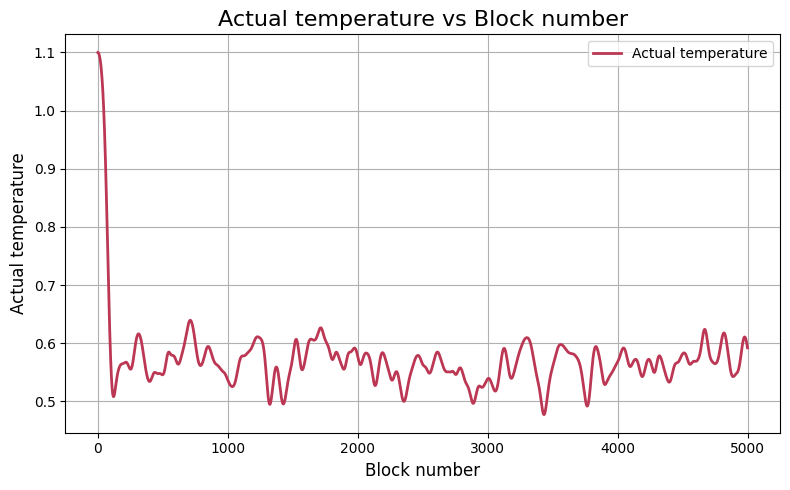

In [2]:
# Percorso del file temperature.dat
filepath_decay = Path("ex07.2/Equilibration/MolecularDynamic/T_decay/temperature.dat")

# Legge i dati dal file
try:
    data_decay = np.loadtxt(filepath_decay, comments="#")  # Legge tutte le colonne
    blocks = data_decay[:, 0]  # Prima colonna: numero di blocchi
    actual_temps = data_decay[:, 1]  # Seconda colonna: temperatura effettiva

    # Plot dei risultati
    plt.figure(figsize=(8, 5))
    plt.plot(blocks, actual_temps, "-", label="Actual temperature", color=color, linewidth=2)
    plt.xlabel("Block number")
    plt.ylabel("Actual temperature")
    plt.title("Actual temperature vs Block number")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
except OSError:
    print(f"Errore: File {filepath_decay} non trovato.")

#### Passo 2: Scan della temperatura di input
L'biettivo è trovare il valore di temperatura di input ( $T_{\text{input}}$ ) che stabilizza ( $T^* = 1.1$ ). I files input.dat e properties.dat vengono così impostati:

```.txt
SIMULATION_TYPE        0
RESTART                0
TEMP                   1.95 , ... , 2.05
NPART                  108
RHO                    0.8
R_CUT                  2.5
DELTA                  0.001
NBLOCKS                5000
NSTEPS                 1
```
```.txt
KINETIC_ENERGY
TEMPERATURE
```
Uno script bash (md_temp_scan.sh) esegue simulazioni per diversi valori di ( $T_{\text{input}}$ ) e salva i risultati in sottodirectory $T\_1.95, T\_1.96, ..., T\_2.05$.
I risultati vengono analizzati per trovare il valore di ( $T_{\text{input}} $) che produce ( $T^* = 1.1 $).

Ad ogni nuova temperatura iniziale, le velocità sono campionate in maniera normale, dipendento proprio da tale temperatura
```c++
vx(i) = _rnd.Gauss(0.,sqrt(_temp));
vy(i) = _rnd.Gauss(0.,sqrt(_temp));
vz(i) = _rnd.Gauss(0.,sqrt(_temp));
```


Il valore di ( $T_{\text{input}}$ ) ottimale è trovato essere ($ T_{\text{input}} = 1.97 $).


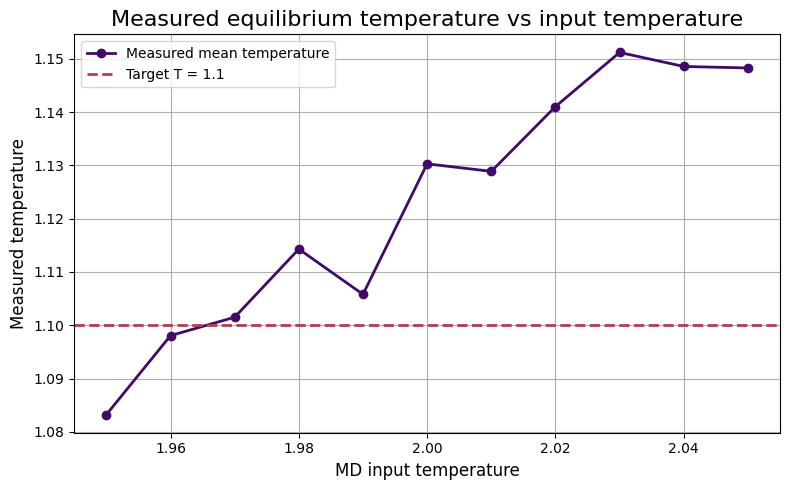

In [3]:
# Funzione per leggere i dati da temperature.dat
def read_block_file(filepath):
    """
    Legge i dati da un file temperature.dat e restituisce un array numpy.
    """
    return np.loadtxt(filepath, comments="#", usecols=(1, 2, 3))  # Legge ACTUAL_T, T_AVE, ERROR

# Percorso base dei dati
base_path = Path("ex07.2/Equilibration/MolecularDynamic/T_analysis")

# Liste per salvare le temperature di input e le medie misurate
temps = []
mean_temps = []

# Ciclo sulle cartelle T_1.95, T_1.96, ..., T_2.05
for folder in sorted(base_path.glob("T_*")):
    T = float(folder.name.split("_")[1])  # Estrae la temperatura dalla cartella
    filepath = folder / "temperature.dat"  # Percorso del file temperature.dat
    
    # Legge i dati dal file
    try:
        data = read_block_file(filepath)
        mean_T = np.mean(data[:, 0])  # Media di ACTUAL_T
        temps.append(T)
        mean_temps.append(mean_T)
    except OSError:
        print(f"Errore: File {filepath} non trovato.")
        continue

# Converte le liste in array numpy
temps = np.array(temps)
mean_temps = np.array(mean_temps)

# Ordina i dati per temperatura di input
idx = np.argsort(temps)
temps = temps[idx]
mean_temps = mean_temps[idx]

# Plot dei risultati
plt.figure(figsize=(8, 5))
plt.plot(temps, mean_temps, "o-", label="Measured mean temperature", color=color2)
plt.axhline(1.1, linestyle="--", color=color, label="Target T = 1.1")
plt.xlabel("MD input temperature")
plt.ylabel("Measured temperature")
plt.title("Measured equilibrium temperature vs input temperature")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Passo 3: simulazione finale
Ora eseguiamo simulazioni MD e MC con il valore ottimale di ( $T_{\text{input}} $) trovato nel passo precedente. Inizializziamo ora i files input.dat e properties.dat in questo modo:

```.dat
SIMULATION_TYPE        0
RESTART                0
TEMP                   1.97
NPART                  108
RHO                    0.8
R_CUT                  2.5
DELTA                  0.001
NBLOCKS                500000
NSTEPS                 1
```
```.dat
POTENTIAL_ENERGY
KINETIC_ENERGY
TEMPERATURE
```

La simulazione MD viene eseguita per ( $5 \times 10^5 $) passi.
I risultati vengono salvati e analizzati per calcolare l'energia potenziale per particella ( $U/N$ ) e la temperatura ($ T $).

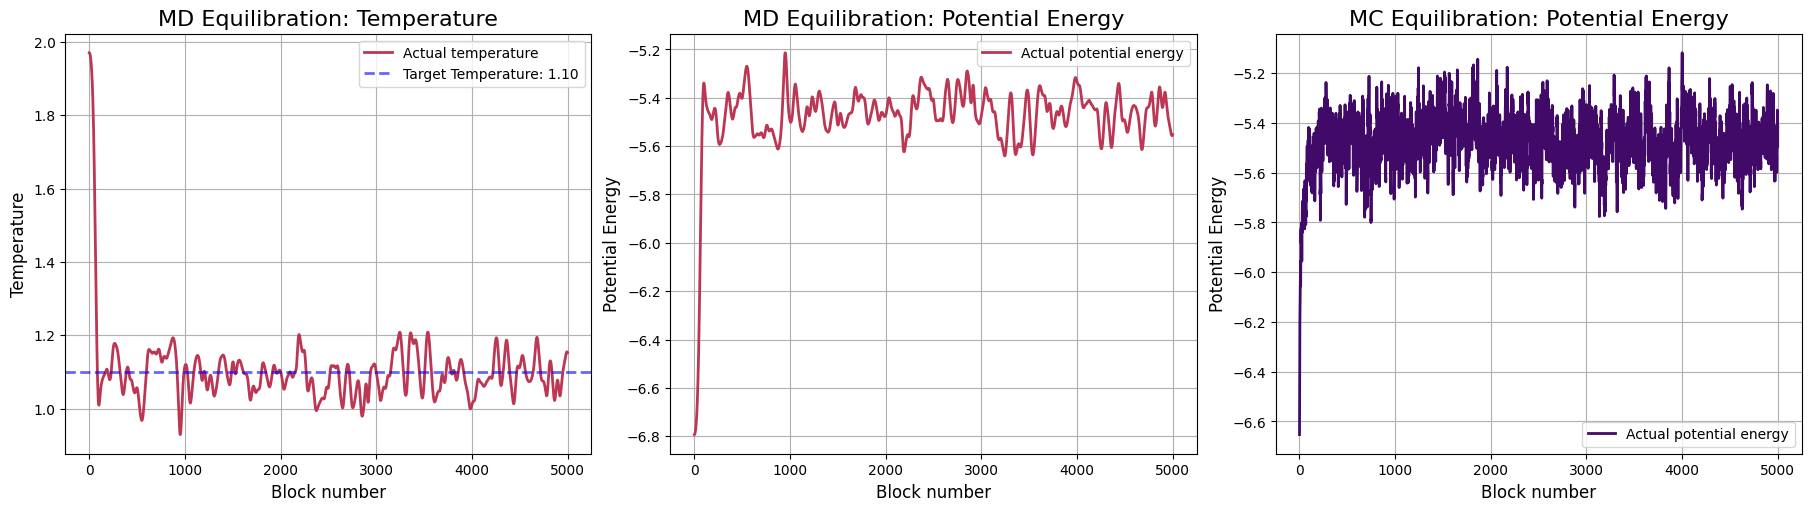

In [4]:
# Percorsi dei file
md_temp_path = Path("ex07.2/Equilibration/MolecularDynamic/MD_equilibration/temperature.dat")
md_potential_path = Path("ex07.2/Equilibration/MolecularDynamic/MD_equilibration/potential_energy.dat")
mc_potential_path = Path("ex07.2/Equilibration/MonteCarlo/MC_equilibration/potential_energy.dat")

# Lettura dei dati
try:
    md_temp_data = np.loadtxt(md_temp_path, comments="#")
    md_potential_data = np.loadtxt(md_potential_path, comments="#")
    mc_potential_data = np.loadtxt(mc_potential_path, comments="#")
    
    # Estrazione delle colonne
    md_temp_blocks = md_temp_data[:, 0]
    md_temp_actual = md_temp_data[:, 1]
    
    md_potential_blocks = md_potential_data[:, 0]
    md_potential_actual = md_potential_data[:, 1]
    
    mc_potential_blocks = mc_potential_data[:, 0]
    mc_potential_actual = mc_potential_data[:, 1]
    
    # Creazione del multiplot
    fig, axs = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    
    # Primo subplot: Temperatura MD
    axs[0].plot(md_temp_blocks, md_temp_actual, "-", color=color, label="Actual temperature")
    axs[0].axhline(1.10, linestyle='--', color='b', alpha=0.6, label=rf'Target Temperature: {1.10:.2f}')
    axs[0].set_xlabel("Block number")
    axs[0].set_ylabel("Temperature")
    axs[0].set_title("MD Equilibration: Temperature")
    axs[0].grid(True)
    axs[0].legend()
    
    # Secondo subplot: Energia potenziale MD
    axs[1].plot(md_potential_blocks, md_potential_actual, "-", color=color, label="Actual potential energy")
    axs[1].set_xlabel("Block number")
    axs[1].set_ylabel("Potential Energy")
    axs[1].set_title("MD Equilibration: Potential Energy")
    axs[1].grid(True)
    axs[1].legend()
    
    # Terzo subplot: Energia potenziale MC
    axs[2].plot(mc_potential_blocks, mc_potential_actual, "-", color=color2, label="Actual potential energy")
    axs[2].set_xlabel("Block number")
    axs[2].set_ylabel("Potential Energy")
    axs[2].set_title("MC Equilibration: Potential Energy")
    axs[2].grid(True)
    axs[2].legend()
    
    # Mostra il grafico
    plt.show()
    
except OSError as e:
    print(f"Errore durante la lettura dei file: {e}")

### Autocorrelazione dell'Energia Potenziale per Particella
La funzione di autocorrelazione per l'energia potenziale per particella $u := U/N$ viene definita come
$$C(k) = \frac{\langle (u_i - \langle u\rangle) (u_{i+k} - \langle u\rangle) \rangle}{\langle (u_i - \langle u \rangle)^2 \rangle } \, ,$$

e misura quanti step della simulazione sono necessari affinché due misure (di energia per particella in questo cas) possono essere trattate come indipendenti. Utilizzeremo questa informazione per una scelta della lunghezza del blocco adeguata, in modo che le medie dei blocchi forniscano una stima affidabile per l'incertezza statistica.

Abbiamo utilizzato $M=5 \times 10^5$ blocchi di step $1$.

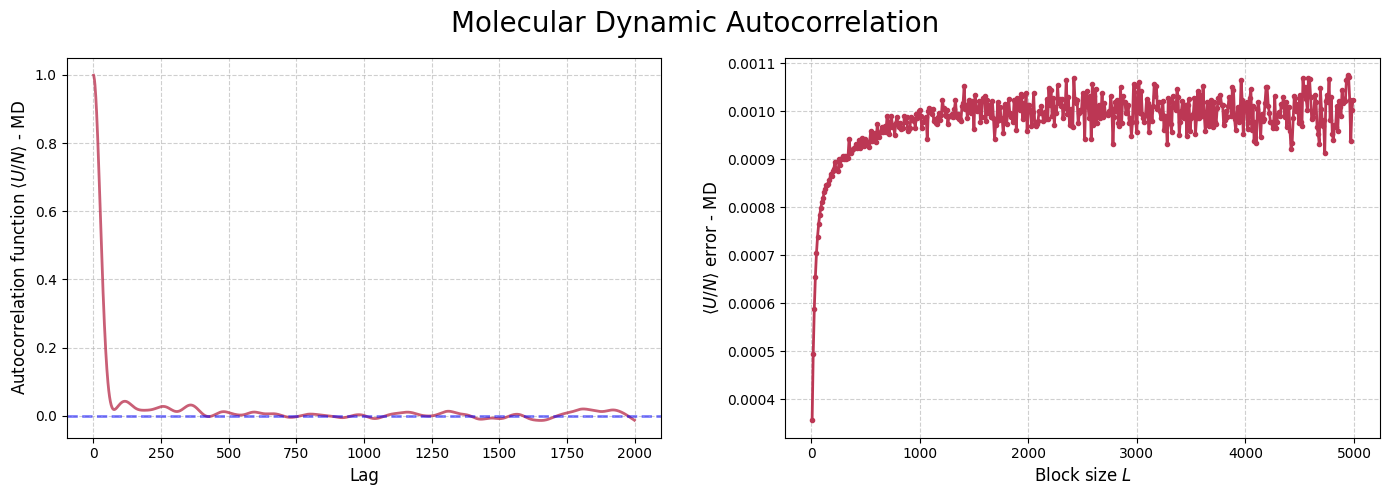

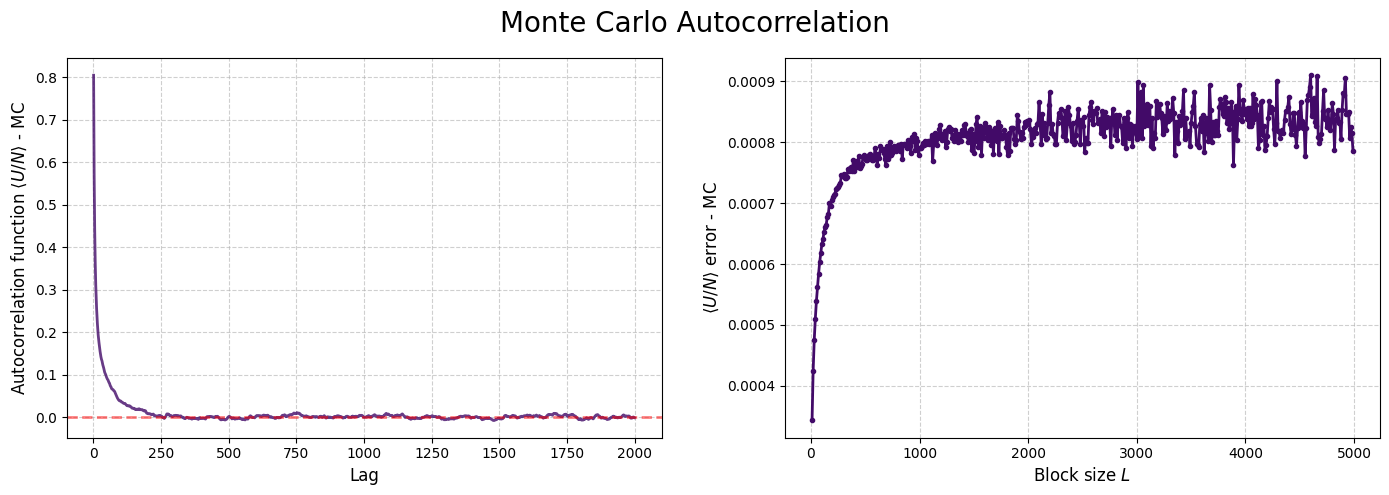

In [5]:
n_throws = 500000
max_lag = 2000
sizes = [10 * i for i in range(1, 500)] 
def autocorr(data, t):
    N = len(data)
    mean = np.mean(data)
    var = np.var(data)
    if var == 0:
        return 0
    sum_prod = np.sum((data[:N - t] - mean) * (data[t:] - mean))
    return sum_prod / ((N - t) * var)

def error(AV, AV2, n):
    if n == 0:
        return 0
    return math.sqrt((AV2[n] - AV[n]**2) / n)

def blockerror(data, N, L):
    ave = np.array([np.mean(data[i*L:(i+1)*L]) for i in range(N)])
    av2 = ave**2
    sum_prog = np.cumsum(ave) / np.arange(1, N+1)
    sum2_prog = np.cumsum(av2) / np.arange(1, N+1)
    return error(sum_prog, sum2_prog, N-1)
file_path_md = "ex07.2/Equilibration/MolecularDynamic/MD_full/potential_energy.dat"
data_md = np.loadtxt(file_path_md, usecols=1, max_rows=n_throws, skiprows=1)

auto_md = [autocorr(data_md, t) for t in range(1, max_lag)]

valid_sizes_md = [L for L in sizes if n_throws // L >= 2]
errors_md = [blockerror(data_md, n_throws // L, L) for L in valid_sizes_md]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, max_lag), auto_md, color=color, alpha=0.8)
axes[0].axhline(0., linestyle='--', color='b', alpha=0.5)
axes[0].set_xlabel("Lag", fontsize=12)
axes[0].set_ylabel("Autocorrelation function $\\langle U/N \\rangle$ - MD",  fontsize=12)
axes[0].grid(True, alpha=0.6, linestyle='--')

axes[1].plot(valid_sizes_md, errors_md, marker='.', color=color)
axes[1].set_xlabel("Block size $L$", fontsize=12)
axes[1].set_ylabel("$\\langle U/N \\rangle$ error - MD", fontsize=12)
axes[1].grid(True, alpha=0.6, linestyle='--')

plt.suptitle("Molecular Dynamic Autocorrelation", fontsize=20)
plt.tight_layout(h_pad=3, w_pad=3)
plt.show()

file_path_mc = "ex07.2/Equilibration/MonteCarlo/MC_full/potential_energy.dat"
data_mc = np.loadtxt(file_path_mc, usecols=1, max_rows=n_throws, skiprows=1)

auto_mc = [autocorr(data_mc, t) for t in range(1, max_lag)]

valid_sizes_mc = [L for L in sizes if n_throws // L >= 2]
errors_mc = [blockerror(data_mc, n_throws // L, L) for L in valid_sizes_mc]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, max_lag), auto_mc, color=color2, alpha=0.8)
axes[0].axhline(0., linestyle='--', color='r', alpha=0.5)
axes[0].set_xlabel("Lag", fontsize=12)
axes[0].set_ylabel("Autocorrelation function $\\langle U/N \\rangle$ - MC",  fontsize=12)
axes[0].grid(True, alpha=0.6, linestyle='--')

axes[1].plot(valid_sizes_mc, errors_mc, marker='.', color=color2)
axes[1].set_xlabel("Block size $L$", fontsize=12)
axes[1].set_ylabel("$\\langle U/N \\rangle$ error - MC", fontsize=12)
axes[1].grid(True, alpha=0.6, linestyle='--')

plt.suptitle("Monte Carlo Autocorrelation", fontsize=20)
plt.tight_layout(h_pad=3, w_pad=3)
plt.show()

___
### Exercise 07.3

Include the calculation of the radial distribution function, $g(r)$, as a function of the radial distance $r$ among particles, with $r \in \left[ 0; L/2\right]$ inside the NSL simulator code: average value of $g(r)$ in each block, final average value of $g(r)$ with statistical uncertainties in a separate file.
___

### Implementation
L'obiettivo dell'esercizio è calcolare la funzione di distribuzione radiale ( $g(r)$ ), che descrive la probabilità di trovare una particella a una distanza ( $r$ ) da una particella di riferimento, rispetto a un sistema ideale uniforme. La funzione ( $g(r)$ ) è calcolata come media sui blocchi e salvata con le sue incertezze. Nel file system.cpp aviene la vera e propria implementazione:

1. **Definizione di ( $g(r)$ ):**
La funzione ( $g(r)$ ) è definita come
$$ g(r) = \frac{V}{N  4\pi r^2 \Delta r}  \frac{\Delta N(r)}{\Delta r}\, ,$$ 
dove:
- ( $V$ ) è il volume del sistema.
- ( $N$ ) è il numero di particelle.
- ( $\Delta N(r)$ ) è il numero di particelle trovate in un intervallo ( $[r, r + \Delta r] $).
- ( $\Delta r$ ) è la larghezza del bin.

2. **Calcolo di ($g(r)$):**
- La funzione measure() calcola ( $\Delta N(r)$ ) per ogni bin ( r ) durante la simulazione.
- I risultati sono accumulati in un vettore _block_av per ciascun blocco.

3. **Normalizzazione:**
La normalizzazione di ( g(r) ) è effettuata nella funzione averages():
```c++
double norm_factor = _volume / (_npart * 4.0 * M_PI * r^2 * _bin_size_g);
_average(_index_gofr + bin) *= norm_factor;
```

4. **output:**
I risultati di ( $g(r)$ ) sono salvati nel file gofr.dat con le seguenti colonne:
- Colonna 1: Numero del blocco.
- Colonna 2: Distanza ( r ).
- Colonna 3: Valore medio ( g(r) ) per il blocco.
- Colonna 4: Media progressiva.
- Colonna 5: Errore progressivo.

___
### Exercise 07.4

By means of your upgraded NSL simulator code, equilibrate and perform MC NVT and MD NVE simulations via a Lennard-Jones model of Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$)

show in pictures the obtained average values and uncertainties for the potential energy per particle, $U/N$, the pressure $P$ and the radial distribution function $g(r)$ in LJ units ...  and compare your MC results for these quantities with those obtained via MD NVE simulations in similar thermodynamic conditions.
___

### Implementation
L'obiettivo dell'esercizio è eseguire simulazioni di Molecular Dynamics (MD) e Monte Carlo (MC) per un sistema Lennard-Jones nelle seguenti condizioni:

- Fase liquida: ( $\rho^* = 0.8 $), ( $T^* = 1.1$ ), ( $r_c^* = 2.5$ ).
- Calcolare e confrontare:
    - Energia potenziale per particella ( $U/N$ ).
    - Pressione ( $P$ ).
    - Funzione di distribuzione radiale ( $g(r)$ ).

Il tutto viene implementato nel file system.cpp nel modo seguente:

1. **Simulazione MD:**
- L'algoritmo di Verlet è utilizzato per integrare le equazioni del moto.
- Le proprietà ( $U/N $), ( $P$ ), e ( $g(r)$ ) sono calcolate nella funzione measure().

2. **Simulazione MC:**
- L'algoritmo di Metropolis è utilizzato per campionare la distribuzione di Boltzmann.
- Le proprietà ( $U/N $), ( $P$ ), e ( $g(r)$ )sono calcolate nella funzione measure(). 

3. **Equilibrazione:**
Entrambe le simulazioni iniziano con una fase di equilibrazione di 2000 passi, implementata nel file NSL_SIMULATOR.cpp:
```c++
for(int i=0; i<2000; i++){
    SYS.step();
}
```

4. **Data Blocking**
- Le simulazioni sono suddivise in ( N_{\text{BLOCKS}} = 100 ) blocchi.
- Per ogni blocco, vengono calcolate le medie e le incertezze progressive utilizzando la funzione averages().

5. **Output:**
I risultati sono salvati nei file:
- potential_energy.dat: Energia potenziale per particella.
- pressure.dat: Pressione.
- gofr.dat: Funzione di distribuzione radiale.

### Fasi della Simulazione
I passaggi per risolvere l'esercizio sono descritti nel file routine.txt.

#### Passo 1: Molecular Dynamic
I files input.dat e properties.dat vengono impostati come:
```.dat
SIMULATION_TYPE        0
RESTART                0
TEMP                   1.97
NPART                  108
RHO                    0.8
R_CUT                  2.5
DELTA                  0.001
NBLOCKS                100
NSTEPS                 5000
```

```.dat
POTENTIAL_ENERGY
PRESSURE
KINETIC_ENERGY
GOFR
```

I risultati sono salvati nella directory OUTPUT_MD.

#### Passo 2: Monte Carlo
I files input.dat e properties.dat vengono impostati come:
```.dat
SIMULATION_TYPE        1
RESTART                0
TEMP                   1.1
NPART                  108
RHO                    0.8
R_CUT                  2.5
DELTA                  0.1
NBLOCKS                100
NSTEPS                 5000
```

```.dat
KINETIC_ENERGY
PRESSURE
```

I risultati sono salvati nella directory OUTPUT_MC.

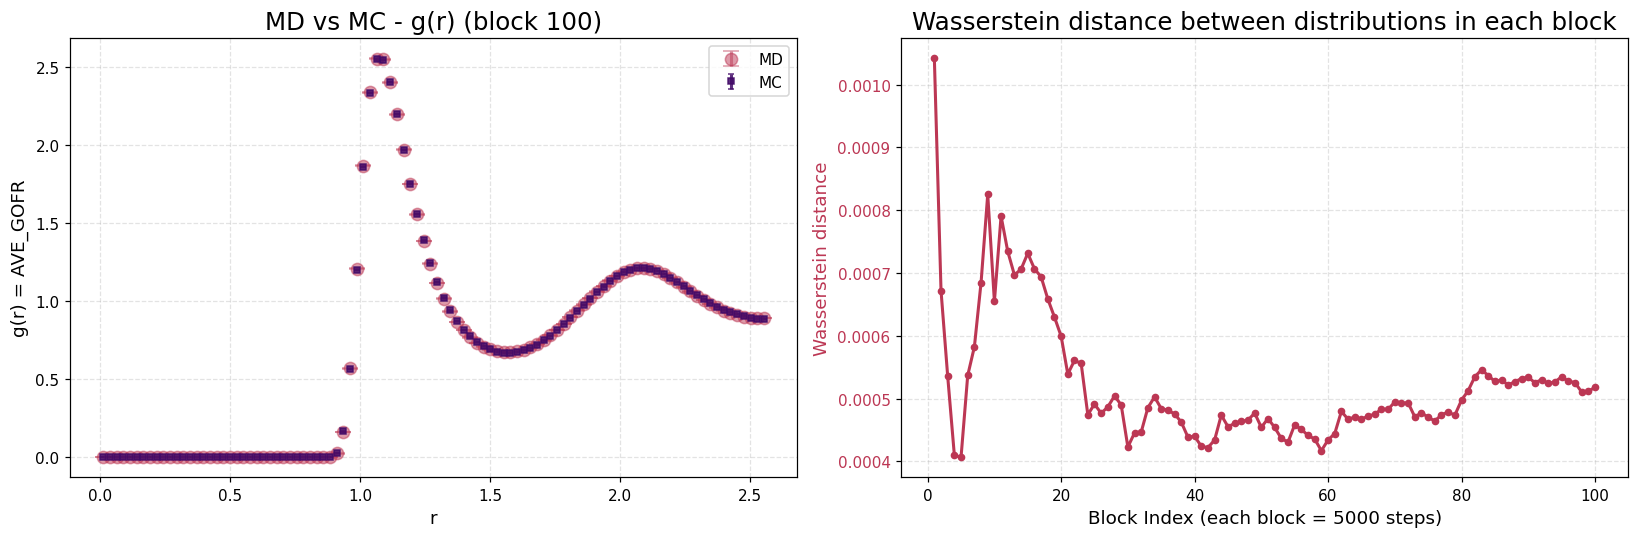

Blocks used: 100 (expected: 100)
Bin per block: 100
Wasserstein last block: 0.000518141


In [6]:
def compare_gr_md_mc_with_metrics(
    file_md,
    file_mc,
    n_blocks_expected=100,
    steps_per_block=5000,
    color_md=color,
    color_mc=color2,
    title_prefix='MD vs MC'
):
    """
    Confronto g(r) MD vs MC in un multiplot (1x2):
      [1] Distribuzioni radiali g(r) (ultimo blocco) con errorbar
      [2] Metriche per blocco: Wasserstein distance

    Formato file gofr.dat atteso (5 colonne):
      0: BLOCK
      1: DISTANCE
      2: ACTUAL_GOFR
      3: AVE_GOFR
      4: ERROR
    """

    # ---------------------------
    # 1) Lettura dati
    # ---------------------------
    md = np.loadtxt(file_md, comments='#', skiprows=1)
    mc = np.loadtxt(file_mc, comments='#', skiprows=1)

    if md.ndim != 2 or md.shape[1] < 5:
        raise ValueError("File MD non conforme: attese almeno 5 colonne.")
    if mc.ndim != 2 or mc.shape[1] < 5:
        raise ValueError("File MC non conforme: attese almeno 5 colonne.")

    # Colonne corrette
    block_md = md[:, 0].astype(int)
    r_md_all = md[:, 1]
    g_md_all = md[:, 3]   # AVE_GOFR
    e_md_all = md[:, 4]   # ERROR

    block_mc = mc[:, 0].astype(int)
    r_mc_all = mc[:, 1]
    g_mc_all = mc[:, 3]   # AVE_GOFR
    e_mc_all = mc[:, 4]   # ERROR

    # ---------------------------
    # 2) Ricavo n_bins dal file
    # ---------------------------
    unique_blocks_md = np.unique(block_md)
    unique_blocks_mc = np.unique(block_mc)

    # blocchi disponibili (intersezione)
    common_blocks = np.intersect1d(unique_blocks_md, unique_blocks_mc)
    if common_blocks.size == 0:
        raise ValueError("Nessun blocco in comune tra file MD e MC.")

    # Se ci sono più blocchi, limitiamo ai primi n_blocks_expected se disponibili
    n_blocks_used = min(common_blocks.size, n_blocks_expected)
    blocks_used = common_blocks[:n_blocks_used]

    # n_bins = quante righe per blocco (assumiamo costante)
    n_bins_md = np.sum(block_md == blocks_used[0])
    n_bins_mc = np.sum(block_mc == blocks_used[0])
    if n_bins_md != n_bins_mc:
        raise ValueError(f"Numero di bin diverso tra MD ({n_bins_md}) e MC ({n_bins_mc}) nel blocco {blocks_used[0]}.")
    n_bins = n_bins_md

    # ---------------------------
    # 3) Costruzione matrici [blocchi, bin]
    # ---------------------------
    def build_block_matrix(block_col, r_col, g_col, e_col, blocks):
        r_mat, g_mat, e_mat = [], [], []
        for b in blocks:
            mask = (block_col == b)
            r_b = r_col[mask]
            g_b = g_col[mask]
            e_b = e_col[mask]

            # ordina per distanza, per sicurezza
            idx = np.argsort(r_b)
            r_mat.append(r_b[idx])
            g_mat.append(g_b[idx])
            e_mat.append(e_b[idx])

        return np.array(r_mat), np.array(g_mat), np.array(e_mat)

    r_md, g_md, e_md = build_block_matrix(block_md, r_md_all, g_md_all, e_md_all, blocks_used)
    r_mc, g_mc, e_mc = build_block_matrix(block_mc, r_mc_all, g_mc_all, e_mc_all, blocks_used)

    # Check griglia r coerente
    if not np.allclose(r_md, r_mc, atol=1e-12, rtol=1e-8):
        raise ValueError("Le griglie DISTANCE di MD e MC non coincidono blocco per blocco.")

    # ---------------------------
    # 4) Metriche per blocco
    # ---------------------------
    eps = 1e-14
    wasserstein_vals = np.full(n_blocks_used, np.nan)

    for i in range(n_blocks_used):
        r_b = r_md[i]
        gmd = g_md[i]
        gmc = g_mc[i]

        # Wasserstein su pesi normalizzati
        w_md = np.clip(gmd, 0, None)
        w_mc = np.clip(gmc, 0, None)

        s_md = np.sum(w_md)
        s_mc = np.sum(w_mc)

        if s_md > eps and s_mc > eps:
            w_md = w_md / s_md
            w_mc = w_mc / s_mc
            wasserstein_vals[i] = wasserstein_distance(r_b, r_b, u_weights=w_md, v_weights=w_mc)

    # ---------------------------
    # 5) Plot 1x2
    # ---------------------------
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=110)

    # (1) g(r) ultimo blocco
    last = -1
    axes[0].errorbar(r_md[last], g_md[last], yerr=e_md[last], fmt='o', ms=8, capsize=5,
                     color=color_md, alpha=0.5, label='MD')
    axes[0].errorbar(r_mc[last], g_mc[last], yerr=e_mc[last], fmt='s', ms=4, capsize=2,
                     color=color_mc, alpha=0.85, label='MC')
    axes[0].set_xlabel('r')
    axes[0].set_ylabel('g(r) = AVE_GOFR')
    axes[0].set_title(f'{title_prefix} - g(r) (block {blocks_used[last]})')
    axes[0].grid(True, ls='--', alpha=0.35)
    axes[0].legend()

    # (2) Wasserstein
    x = np.arange(1, n_blocks_used + 1)

    axes[1].plot(x, wasserstein_vals, '-o', ms=4, color=color, label='Wasserstein')
    axes[1].set_xlabel(f'Block Index (each block = {steps_per_block} steps)')
    axes[1].set_ylabel('Wasserstein distance', color=color)
    axes[1].tick_params(axis='y', labelcolor=color)
    axes[1].grid(True, ls='--', alpha=0.35)
    axes[1].set_title('Wasserstein distance between distributions in each block')

    plt.tight_layout()
    plt.show()

    print(f"Blocks used: {n_blocks_used} (expected: {n_blocks_expected})")
    print(f"Bin per block: {n_bins}")
    print(f"Wasserstein last block: {wasserstein_vals[-1]:.6g}")

    return {
        "blocks_used": blocks_used,
        "n_blocks_used": n_blocks_used,
        "n_bins": n_bins,
        "wasserstein_per_block": wasserstein_vals,
    }


results = compare_gr_md_mc_with_metrics(
    file_md="ex07.4/OUTPUT_MD/gofr.dat",
    file_mc="ex07.4/OUTPUT_MC/gofr.dat",
    n_blocks_expected=100,
    steps_per_block=5000
)

### Distanza di Wasserstein
La distanza di Wasserstein (o distanza tra trasporto di massa) misura la differenza tra due distribuzioni considerando sia la posizione che il peso dei valori. È particolarmente utile per confrontare distribuzioni che possono differire in modo più sottile rispetto al test di Chi-quadro.

La distanza di Wasserstein è calcolata come: $$ W = \int_0^\infty |G_{\text{MD}}(r) - G_{\text{MC}}(r)| \, dr $$ dove ( $G_{\text{MD}}(r) $) e ( $G_{\text{MC}}(r)$ ) sono le distribuzioni cumulative di ($ g(r)$ ) per MD e MC.

- ($ W = 0 $): Le due distribuzioni sono identiche.
- ($ W > 0 $): Maggiore è il valore di ( W ), maggiore è la discrepanza tra le distribuzioni.

Il vantaggio rispetto a test come quello del chi-quadro è che non richiede l'assunzione di incertezze sui dati.
È sensibile a differenze nella forma globale delle distribuzioni, non solo nei singoli bin.

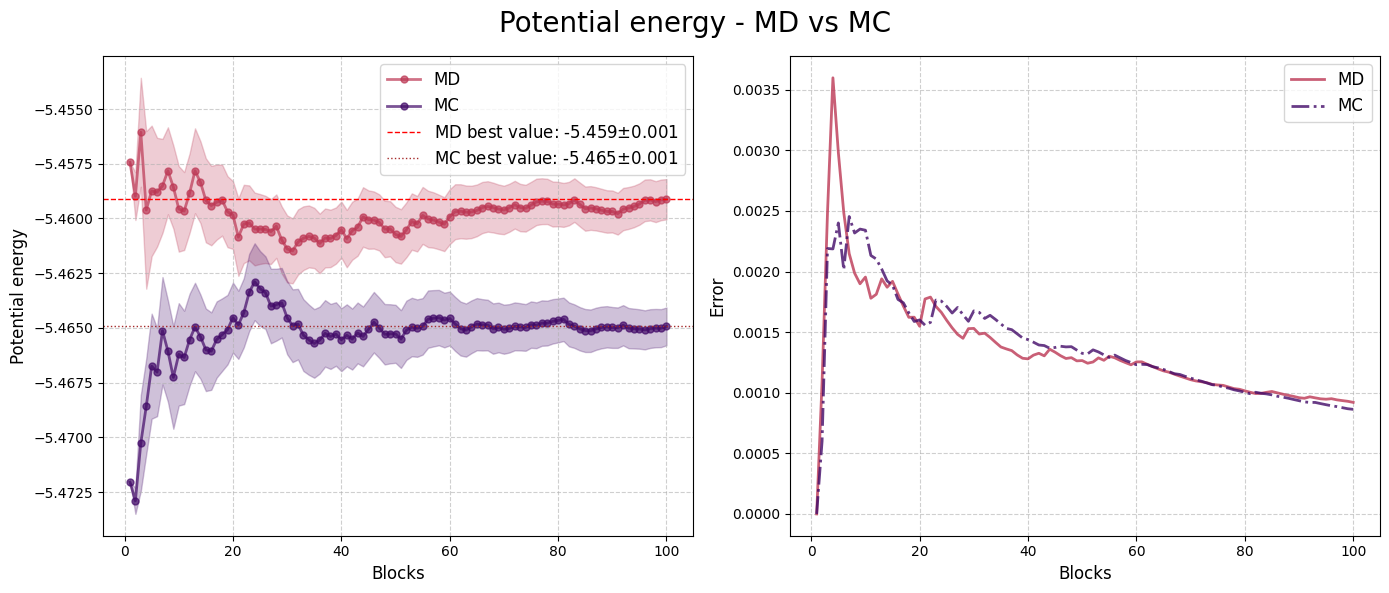

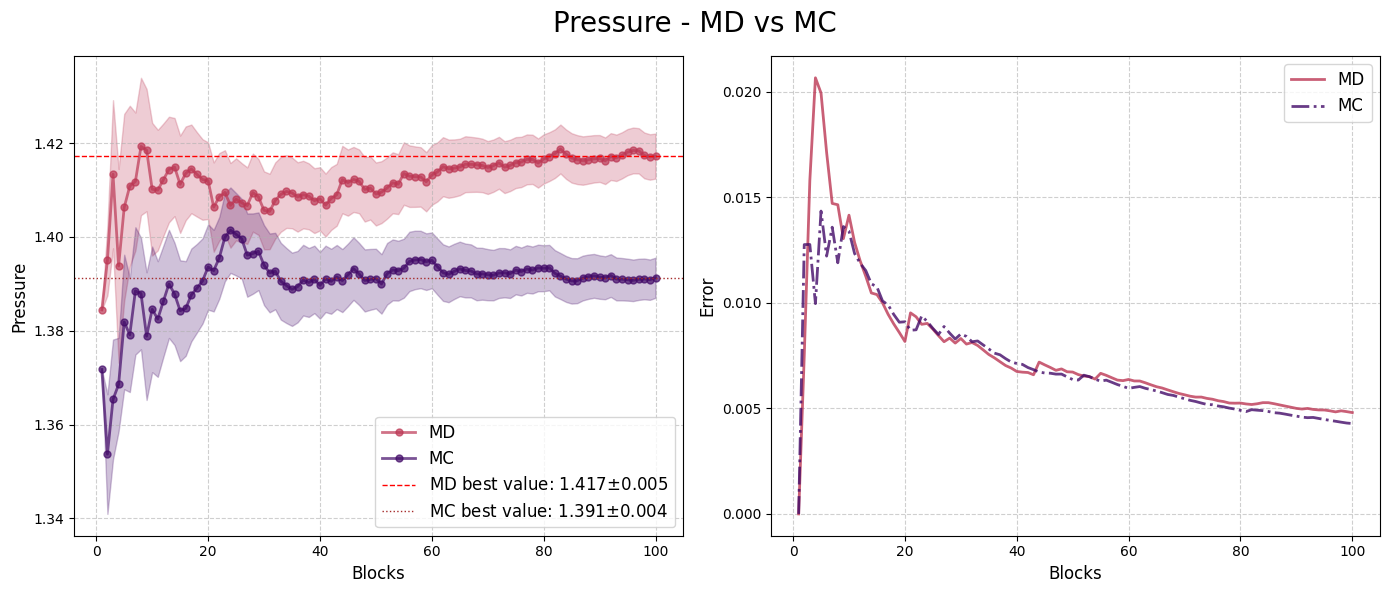

In [10]:
def plot_MD_vs_MC(file_MD, file_MC, ylabel):
    x_MD, E_MD, err_MD = np.loadtxt(file_MD, usecols=(0, 2, 3), unpack=True, comments='#', skiprows=1)
    x_MC, E_MC, err_MC = np.loadtxt(file_MC, usecols=(0, 2, 3), unpack=True, comments='#', skiprows=1)

    fig, axs = plt.subplots(1, 2, figsize=(14, 6), dpi=100, sharex=True)
    
    
    axs[0].plot(x_MD, E_MD, 'o-', color=color, alpha=0.7, markersize=5,label='MD')
    axs[0].plot(x_MC, E_MC, 'o-', color=color2, alpha=0.7, markersize=5,label='MC')
    axs[0].fill_between(x_MD, E_MD-err_MD, E_MD+err_MD,
                       color=color, alpha=0.25)
    axs[0].fill_between(x_MC, E_MC-err_MC, E_MC+err_MC,
                       color=color2, alpha=0.25)
    axs[0].set_xlabel('Blocks', fontsize=12)
    axs[0].set_ylabel(ylabel, fontsize=12)
    axs[0].axhline(y=E_MD[-1], color='r', linestyle='--', linewidth=1,
                 label=rf'MD best value: {E_MD[-1]:.3f}$\pm${err_MD[-1]:.3f}')
    axs[0].axhline(y=E_MC[-1], color='brown', linestyle=':', linewidth=1,
                 label=rf'MC best value: {E_MC[-1]:.3f}$\pm${err_MC[-1]:.3f}')
    axs[0].legend(fontsize=12)
    axs[0].grid(True, alpha=0.6, linestyle='--')
    
    axs[1].plot(x_MD, err_MD,'-', color=color, alpha=0.8, label='MD')
    axs[1].plot(x_MC, err_MC,'-.', color=color2, alpha=0.8, label='MC')
    axs[1].set_xlabel('Blocks', fontsize=12)
    axs[1].set_ylabel('Error', fontsize=12)
    axs[1].legend(fontsize=12)
    axs[1].grid(True, alpha=0.6, linestyle='--')
    
    plt.suptitle(f'{ylabel} - MD vs MC', fontsize=20)
    plt.tight_layout()
    plt.show()
    
plot_MD_vs_MC("ex07.4/OUTPUT_MD/potential_energy.dat", "ex07.4/OUTPUT_MC/potential_energy.dat",'Potential energy')
plot_MD_vs_MC("ex07.4/OUTPUT_MD/pressure.dat", "ex07.4/OUTPUT_MC/pressure.dat",'Pressure')

### Supplementary activity ... just for your fun!
Note that he following **is not** part of the Numerical Exercise 7; if you had fun with exercises 7.* and you are courious, you could try to repeat exercises 7.2 and 7.4 in the following different thermodynamic conditions:
- solid phase: $\rho^\star = 1.1$, $T^\star = 0.8$ (cut-off radius: $r^\star_c = 2.2$)
- gas phase: $\rho^\star = 0.05$, $T^\star = 1.2$ (cut-off radius: $r^\star_c = 5.0$)